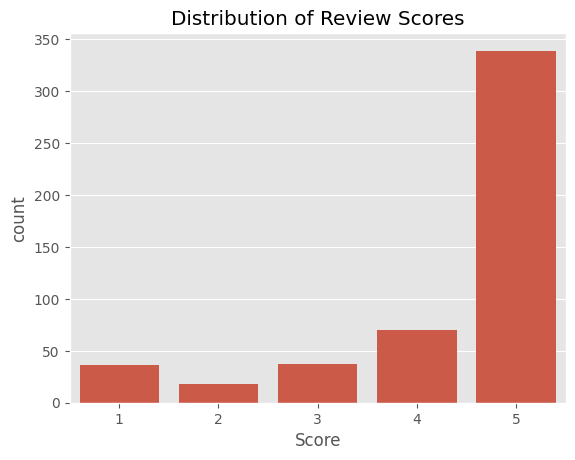

[nltk_data] Downloading package vader_lexicon to /root/nltk_data...
/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/747 [00:00<?, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/150 [00:00<?, ?B/s]

pytorch_model.bin:   0%|          | 0.00/499M [00:00<?, ?B/s]

  0%|          | 0/500 [00:00<?, ?it/s]

model.safetensors:   0%|          | 0.00/499M [00:00<?, ?B/s]

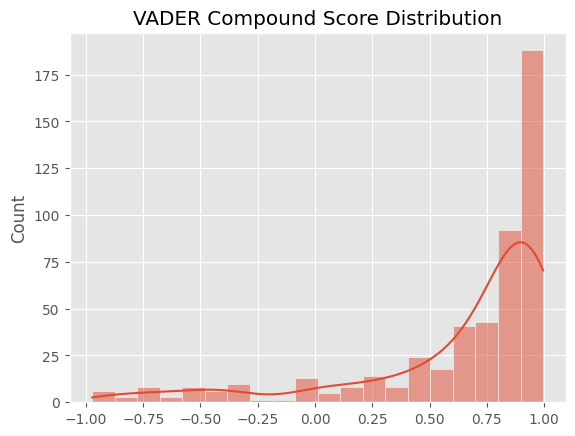

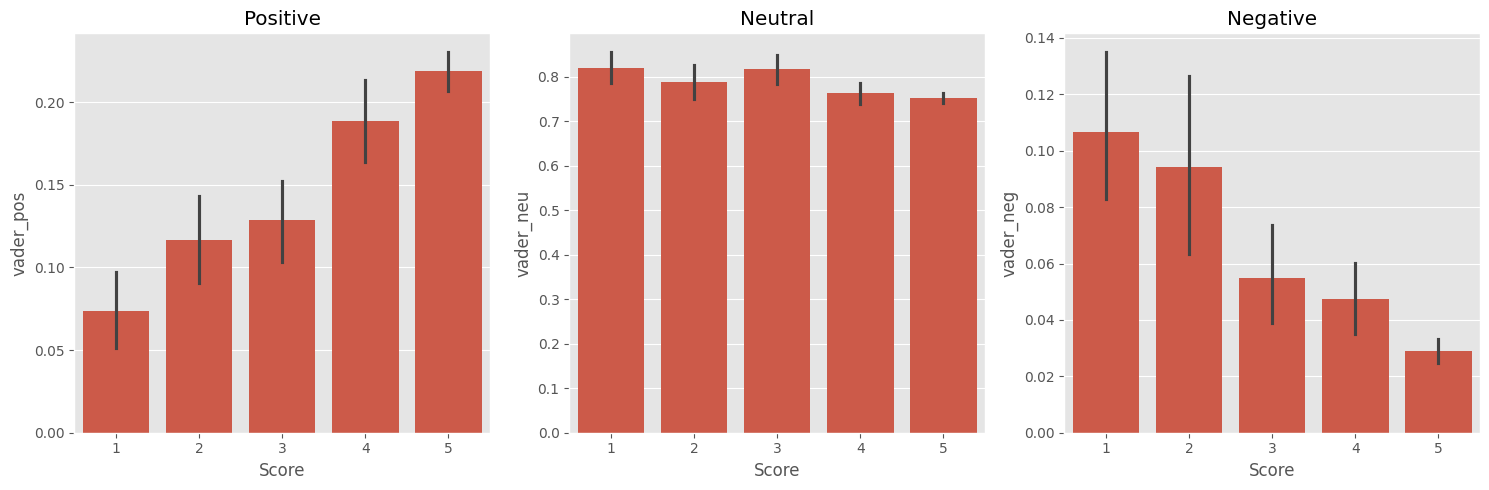

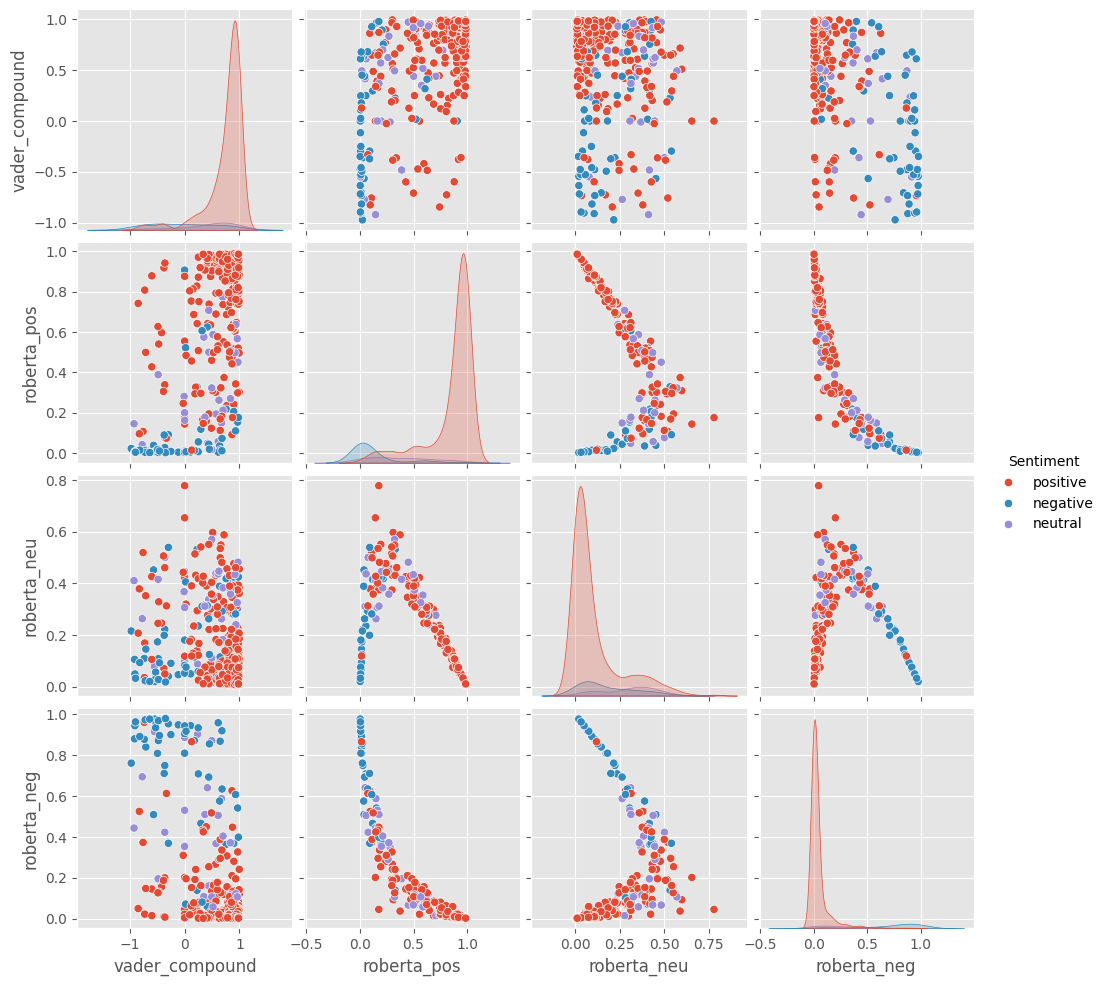

Training samples: 400, Testing samples: 100
Accuracy: 87.00%
Precision: 83.55%
Recall: 87.00%
F1 Score: 85.23%


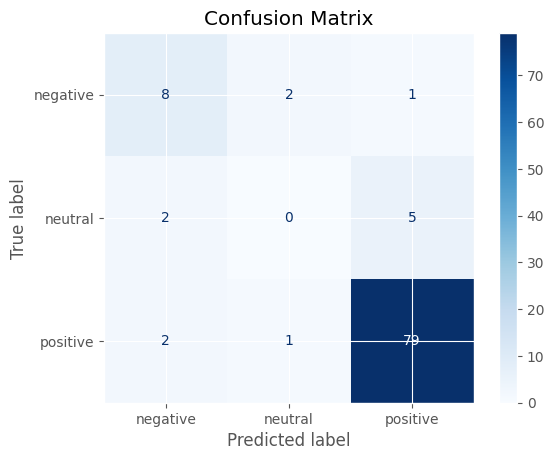

In [ ]:
# 1. Import Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import nltk
from nltk.sentiment import SentimentIntensityAnalyzer
from tqdm.notebook import tqdm
from transformers import AutoTokenizer, AutoModelForSequenceClassification
from scipy.special import softmax
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, confusion_matrix, ConfusionMatrixDisplay
)

# Set plotting style
plt.style.use('ggplot')

# 2. Load Data
df = pd.read_csv("Reviews.csv", engine='python', on_bad_lines='skip')
df = df.head(500)  # Reduce sample size for faster testing

# Convert Score to Sentiment classes
def score_to_sentiment(score):
    if score <= 2:
        return 'negative'
    elif score == 3:
        return 'neutral'
    else:
        return 'positive'

df['Sentiment'] = df['Score'].apply(score_to_sentiment)

# Plot review score distribution
sns.countplot(data=df, x='Score')
plt.title('Distribution of Review Scores')
plt.show()

# 3. NLTK setup
nltk.download('vader_lexicon')
sia = SentimentIntensityAnalyzer()

# 4. RoBERTa model setup
MODEL = "cardiffnlp/twitter-roberta-base-sentiment"
tokenizer = AutoTokenizer.from_pretrained(MODEL)
model = AutoModelForSequenceClassification.from_pretrained(MODEL)

def polarity_scores_roberta(text):
    encoded_text = tokenizer(text, return_tensors='pt', truncation=True, max_length=512)
    output = model(**encoded_text)
    scores = output[0][0].detach().numpy()
    scores = softmax(scores)
    return [scores[0], scores[1], scores[2]]  # neg, neu, pos

# 5. Generate features (VADER + RoBERTa)
features = []
labels = []

for i, row in tqdm(df.iterrows(), total=len(df)):
    text = row['Text']
    vader_result = sia.polarity_scores(text)
    roberta_result = polarity_scores_roberta(text)

    feat = [
        vader_result['neg'], vader_result['neu'], vader_result['pos'], vader_result['compound'],
        roberta_result[0], roberta_result[1], roberta_result[2]
    ]

    features.append(feat)
    labels.append(row['Sentiment'])

X = np.array(features)
y = np.array(labels)

# Encode labels
le = LabelEncoder()
y_encoded = le.fit_transform(y)

# 6. Visualizations

# VADER compound score distribution
vader_compound_scores = [f[3] for f in features]
sns.histplot(vader_compound_scores, bins=20, kde=True)
plt.title('VADER Compound Score Distribution')
plt.show()

# Sentiment vs Score comparison
df_vader = df.copy()
df_vader['vader_neg'] = [f[0] for f in features]
df_vader['vader_neu'] = [f[1] for f in features]
df_vader['vader_pos'] = [f[2] for f in features]
df_vader['vader_compound'] = [f[3] for f in features]

fig, axs = plt.subplots(1, 3, figsize=(15, 5))
sns.barplot(x='Score', y='vader_pos', data=df_vader, ax=axs[0])
axs[0].set_title('Positive')

sns.barplot(x='Score', y='vader_neu', data=df_vader, ax=axs[1])
axs[1].set_title('Neutral')

sns.barplot(x='Score', y='vader_neg', data=df_vader, ax=axs[2])
axs[2].set_title('Negative')

plt.tight_layout()
plt.show()

# Pairplot VADER vs RoBERTa
df_pair = df_vader.copy()
df_pair['roberta_neg'] = [f[4] for f in features]
df_pair['roberta_neu'] = [f[5] for f in features]
df_pair['roberta_pos'] = [f[6] for f in features]

sns.pairplot(
    data=df_pair,
    vars=["vader_compound", "roberta_pos", "roberta_neu", "roberta_neg"],
    hue="Sentiment"
)
plt.show()

# 7. Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y_encoded, test_size=0.2, random_state=42, stratify=y_encoded
)
print(f"Training samples: {len(X_train)}, Testing samples: {len(X_test)}")

# 8. Train classifier
clf = RandomForestClassifier(n_estimators=200, random_state=42)
clf.fit(X_train, y_train)

# 9. Evaluate model
y_pred = clf.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred, average='weighted')
recall = recall_score(y_test, y_pred, average='weighted')
f1 = f1_score(y_test, y_pred, average='weighted')

print(f"Accuracy: {accuracy*100:.2f}%")
print(f"Precision: {precision*100:.2f}%")
print(f"Recall: {recall*100:.2f}%")
print(f"F1 Score: {f1*100:.2f}%")

# 10. Confusion matrix
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=le.classes_)
disp.plot(cmap=plt.cm.Blues)
plt.title('Confusion Matrix')
plt.show()